# Assignment 2: Prostate Lesion Detection (Zero-Shot)
**Objective**: Build a pipeline to use an existing pretrained model to detect whether a suspicious lesion is present on Prostate MRI (AIIMS Dataset) and perform patient-level and slice-level evaluation.

We also include **Explainable AI (XAI)** by generating heatmaps over the MRI slices to visualize the network's focal points (where it predicts lesions).

In [1]:
!pip install -q monai torch torchvision picai_eval picai_baseline SimpleITK scikit-learn pandas matplotlib

In [ ]:
import os
import torch
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
import csv
from collections import defaultdict
from tqdm.notebook import tqdm
from sklearn.metrics import roc_auc_score, average_precision_score

from monai.networks.nets import UNet
from report_guided_annotation import extract_lesion_candidates

# Path settings 
DATASET_DIR = r"dataset" 
IMAGES_DIR = os.path.join(DATASET_DIR, "images")
LABELS_CSV = os.path.join(DATASET_DIR, "labels_dev.csv")
SLICE_LABELS_CSV = os.path.join(DATASET_DIR, "slice_labels_dev.csv")
SPLIT_CSV = os.path.join(DATASET_DIR, "split.csv")
WEIGHTS_PATH = r"weights\picai_unet_semi_supervised.pth" # We will download this below




Please cite the following paper when using Report Guided Annotations:

Bosma, J.S., et al. "Semi-supervised learning with report-guided lesion annotation for deep learning-based prostate cancer detection in bpMRI" to be submitted


If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/Report-Guided-Annotation



### Download Pretrained PI-CAI U-Net Weights

In [3]:
import urllib.request

unet_url = "https://media.githubusercontent.com/media/DIAGNijmegen/picai_unet_semi_supervised_gc_algorithm/main/weights/unet_F0.pt"
if not os.path.exists(WEIGHTS_PATH):
    print("Downloading weights...")
    urllib.request.urlretrieve(unet_url, WEIGHTS_PATH)
    print("Download complete.")
else:
    print("Weights already downloaded.")


Weights already downloaded.


### Preprocessing Pipeline
Normalizes T2/DWI (z-score), ADC (min-max), and resamples to PI-CAI standards.

In [4]:
def resample_volume(sitk_image, target_spacing=(0.5, 0.5, 3.0)):
    target_spacing_xyz = np.array([target_spacing[1], target_spacing[0], target_spacing[2]])
    original_size = np.array(sitk_image.GetSize())
    original_spacing = np.array(sitk_image.GetSpacing())
    new_size = np.round(original_size * original_spacing / target_spacing_xyz).astype(int).tolist()
    
    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(target_spacing_xyz.tolist())
    resampler.SetSize(new_size)
    resampler.SetOutputDirection(sitk_image.GetDirection())
    resampler.SetOutputOrigin(sitk_image.GetOrigin())
    resampler.SetTransform(sitk.Transform())
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetDefaultPixelValue(0)
    return resampler.Execute(sitk_image)

def crop_or_pad(volume, target_size=(20, 256, 256)):
    result = np.zeros(target_size, dtype=volume.dtype)
    offsets = []
    slices_src, slices_dst = [], []
    for i in range(3):
        src_size = volume.shape[i]
        tgt_size = target_size[i]
        if src_size > tgt_size:
            start = (src_size - tgt_size) // 2
            slices_src.append(slice(start, start + tgt_size))
            slices_dst.append(slice(0, tgt_size))
            offsets.append(start)
        else:
            start = (tgt_size - src_size) // 2
            slices_src.append(slice(0, src_size))
            slices_dst.append(slice(start, start + src_size))
            offsets.append(-start)
    result[slices_dst[0], slices_dst[1], slices_dst[2]] = volume[slices_src[0], slices_src[1], slices_src[2]]
    return result, tuple(offsets)

def preprocess_case(case_dir):
    t2_sitk = sitk.ReadImage(os.path.join(case_dir, "t2.nii.gz"), sitk.sitkFloat32)
    adc_sitk = sitk.ReadImage(os.path.join(case_dir, "adc.nii.gz"), sitk.sitkFloat32)
    dwi_sitk = sitk.ReadImage(os.path.join(case_dir, "dwi_highb.nii.gz"), sitk.sitkFloat32)
    
    meta = {
        "original_spacing": t2_sitk.GetSpacing(),
        "original_size": t2_sitk.GetSize(),
        "original_origin": t2_sitk.GetOrigin(),
        "original_direction": t2_sitk.GetDirection(),
    }
    
    t2_sitk = resample_volume(t2_sitk)
    adc_sitk = resample_volume(adc_sitk)
    dwi_sitk = resample_volume(dwi_sitk)
    
    t2 = sitk.GetArrayFromImage(t2_sitk)
    adc = sitk.GetArrayFromImage(adc_sitk)
    dwi = sitk.GetArrayFromImage(dwi_sitk)
    
    meta["resampled_shape"] = t2.shape
    
    # Normalize
    t2 = np.clip(t2, np.percentile(t2[t2>0], 0.5), np.percentile(t2[t2>0], 99.5))
    t2 = (t2 - t2.mean()) / (t2.std() + 1e-8)
    
    dwi = np.clip(dwi, np.percentile(dwi[dwi>0], 0.5), np.percentile(dwi[dwi>0], 99.5))
    dwi = (dwi - dwi.mean()) / (dwi.std() + 1e-8)
    
    adc = np.clip(adc, 0, 3000) / 3000.0
    
    # Crop/Pad
    t2, offset = crop_or_pad(t2)
    adc, _ = crop_or_pad(adc)
    dwi, _ = crop_or_pad(dwi)
    meta["crop_offsets"] = offset
    
    vol = np.stack([t2, adc, dwi], axis=0).astype(np.float32)
    return vol, meta


### Model Setup (PI-CAI U-Net)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(
    spatial_dims=3, 
    in_channels=3, 
    out_channels=2,
    strides=[(2, 2, 2), (1, 2, 2), (1, 2, 2), (1, 2, 2), (2, 2, 2)],
    channels=[32, 64, 128, 256, 512, 1024]
)

ckpt = torch.load(WEIGHTS_PATH, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
model.to(device)

def predict(volume):
    inp = torch.from_numpy(volume).unsqueeze(0).float().to(device)
    with torch.no_grad():
        logits = model(inp)
        probs = torch.softmax(logits, dim=1)
        fg_prob = probs[0, 1].cpu().numpy()
    return fg_prob


### Explainable AI (XAI) Visualizer
Medical imaging models are naturally explainable through their spatial probability maps. We overlay the probability map on the T2 scan to show **where** the model thinks the cancer is.

In [6]:
def visualize_xai(t2_volume, prob_map, case_code, slice_idx=10):
    """Plots the T2 slice alongside the XAI heatmap."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    t2_slice = t2_volume[slice_idx]
    prob_slice = prob_map[slice_idx]
    
    axes[0].imshow(t2_slice, cmap='gray')
    axes[0].set_title(f"T2 MRI (Slice {slice_idx})")
    axes[0].axis('off')
    
    axes[1].imshow(prob_slice, cmap='jet', vmin=0, vmax=1)
    axes[1].set_title(f"Model Probability Heatmap")
    axes[1].axis('off')
    
    axes[2].imshow(t2_slice, cmap='gray')
    axes[2].imshow(prob_slice, cmap='jet', alpha=0.4, vmin=0, vmax=1) # Overlay
    axes[2].set_title(f"Explainable AI Overlay")
    axes[2].axis('off')
    
    plt.suptitle(f"XAI Localization for {case_code}", fontsize=16)
    plt.show()


### Run Evaluation 

Found 97 patient cases.

Testing Patient: C0001
Path: dataset\images\C0001

All MRI files found.

Preprocessing patient...
Preprocessing completed.
Volume shape: (3, 20, 256, 256)

Running model prediction...
Prediction completed.
Probability map shape: (20, 256, 256)

Patient Level Risk Score: 0.9877
Highest probability slice: 7
Maximum model probability: 0.9877


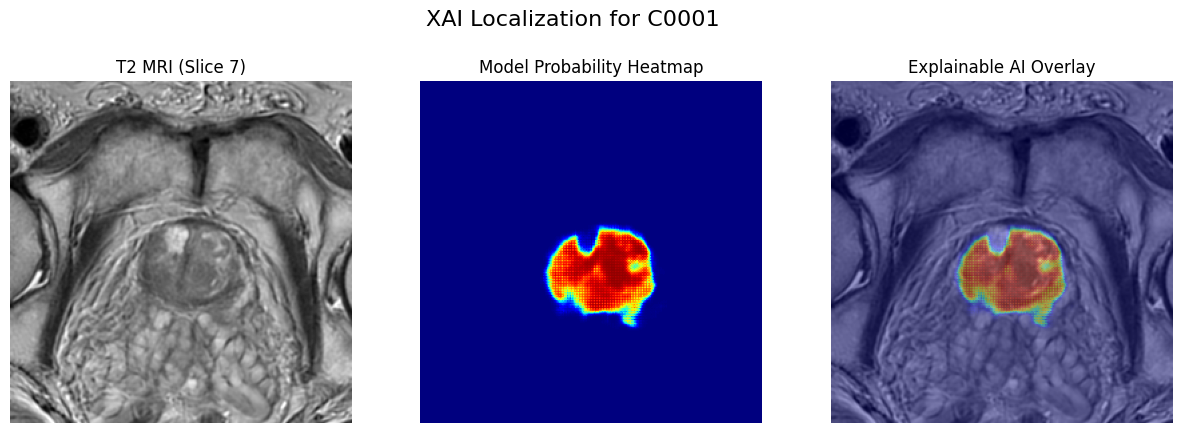

In [7]:
# ============================================================
# LOCAL TEST - SINGLE PATIENT
# ============================================================

import os
import glob
import numpy as np

# Find patient/case directories
test_cases = [
    path for path in glob.glob(os.path.join(IMAGES_DIR, "*"))
    if os.path.isdir(path)
]

print(f"Found {len(test_cases)} patient cases.")

if len(test_cases) == 0:

    print("\nNo patient cases found.")
    print("Please check your IMAGES_DIR:")
    print(IMAGES_DIR)

else:

    # --------------------------------------------------------
    # Select first patient
    # --------------------------------------------------------
    sample_case = test_cases[0]

    case_code = os.path.basename(
        os.path.normpath(sample_case)
    )

    print("\n========================================")
    print(f"Testing Patient: {case_code}")
    print(f"Path: {sample_case}")
    print("========================================")

    # --------------------------------------------------------
    # Check required MRI files
    # --------------------------------------------------------
    required_files = [
        "t2.nii.gz",
        "adc.nii.gz",
        "dwi_highb.nii.gz"
    ]

    missing_files = []

    for filename in required_files:

        filepath = os.path.join(
            sample_case,
            filename
        )

        if not os.path.exists(filepath):
            missing_files.append(filename)

    if missing_files:

        print("\nERROR: Missing MRI files:")

        for filename in missing_files:
            print(" -", filename)

    else:

        print("\nAll MRI files found.")

        # ----------------------------------------------------
        # Preprocessing
        # ----------------------------------------------------
        print("\nPreprocessing patient...")

        vol, meta = preprocess_case(sample_case)

        print("Preprocessing completed.")
        print("Volume shape:", vol.shape)

        # Expected:
        # (3, 20, 256, 256)

        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------
        print("\nRunning model prediction...")

        prob_map = predict(vol)

        print("Prediction completed.")
        print("Probability map shape:", prob_map.shape)

        # ----------------------------------------------------
        # Patient-level lesion score
        # ----------------------------------------------------
        lesion_map = extract_lesion_candidates(
            prob_map,
            threshold="dynamic"
        )[0]

        patient_score = float(
            np.max(lesion_map)
        )

        print(
            f"\nPatient Level Risk Score: "
            f"{patient_score:.4f}"
        )

        # ----------------------------------------------------
        # Find highest-probability slice
        # ----------------------------------------------------
        slice_scores = np.max(
            prob_map,
            axis=(1, 2)
        )

        best_slice = int(
            np.argmax(slice_scores)
        )

        print(
            f"Highest probability slice: "
            f"{best_slice}"
        )

        print(
            f"Maximum model probability: "
            f"{slice_scores[best_slice]:.4f}"
        )

        # ----------------------------------------------------
        # XAI Visualization
        # ----------------------------------------------------
        visualize_xai(
            vol[0],
            prob_map,
            case_code,
            slice_idx=best_slice
        )

Found 97 patient cases.

Testing Patient: C0002
Path: dataset\images\C0002

All MRI files found.

Preprocessing patient...
Preprocessing completed.
Volume shape: (3, 20, 256, 256)

Running model prediction...
Prediction completed.
Probability map shape: (20, 256, 256)

Patient Level Risk Score: 0.0687
Highest probability slice: 12
Maximum model probability: 0.0687


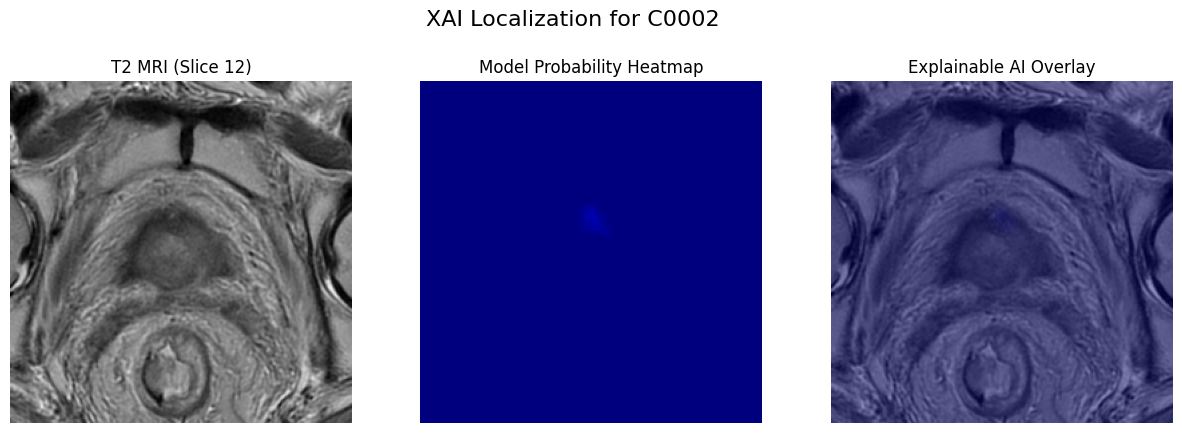

In [8]:
# ============================================================
# LOCAL TEST - SINGLE PATIENT
# ============================================================

import os
import glob
import numpy as np

# Find patient/case directories
test_cases = [
    path for path in glob.glob(os.path.join(IMAGES_DIR, "*"))
    if os.path.isdir(path)
]

print(f"Found {len(test_cases)} patient cases.")

if len(test_cases) == 0:

    print("\nNo patient cases found.")
    print("Please check your IMAGES_DIR:")
    print(IMAGES_DIR)

else:

    # --------------------------------------------------------
    # Select first patient
    # --------------------------------------------------------
    sample_case = test_cases[1]

    case_code = os.path.basename(
        os.path.normpath(sample_case)
    )

    print("\n========================================")
    print(f"Testing Patient: {case_code}")
    print(f"Path: {sample_case}")
    print("========================================")

    # --------------------------------------------------------
    # Check required MRI files
    # --------------------------------------------------------
    required_files = [
        "t2.nii.gz",
        "adc.nii.gz",
        "dwi_highb.nii.gz"
    ]

    missing_files = []

    for filename in required_files:

        filepath = os.path.join(
            sample_case,
            filename
        )

        if not os.path.exists(filepath):
            missing_files.append(filename)

    if missing_files:

        print("\nERROR: Missing MRI files:")

        for filename in missing_files:
            print(" -", filename)

    else:

        print("\nAll MRI files found.")

        # ----------------------------------------------------
        # Preprocessing
        # ----------------------------------------------------
        print("\nPreprocessing patient...")

        vol, meta = preprocess_case(sample_case)

        print("Preprocessing completed.")
        print("Volume shape:", vol.shape)

        # Expected:
        # (3, 20, 256, 256)

        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------
        print("\nRunning model prediction...")

        prob_map = predict(vol)

        print("Prediction completed.")
        print("Probability map shape:", prob_map.shape)

        # ----------------------------------------------------
        # Patient-level lesion score
        # ----------------------------------------------------
        lesion_map = extract_lesion_candidates(
            prob_map,
            threshold="dynamic"
        )[0]

        patient_score = float(
            np.max(lesion_map)
        )

        print(
            f"\nPatient Level Risk Score: "
            f"{patient_score:.4f}"
        )

        # ----------------------------------------------------
        # Find highest-probability slice
        # ----------------------------------------------------
        slice_scores = np.max(
            prob_map,
            axis=(1, 2)
        )

        best_slice = int(
            np.argmax(slice_scores)
        )

        print(
            f"Highest probability slice: "
            f"{best_slice}"
        )

        print(
            f"Maximum model probability: "
            f"{slice_scores[best_slice]:.4f}"
        )

        # ----------------------------------------------------
        # XAI Visualization
        # ----------------------------------------------------
        visualize_xai(
            vol[0],
            prob_map,
            case_code,
            slice_idx=best_slice
        )

Found 97 patient cases.

Testing Patient: C0004
Path: dataset\images\C0004

All MRI files found.

Preprocessing patient...
Preprocessing completed.
Volume shape: (3, 20, 256, 256)

Running model prediction...
Prediction completed.
Probability map shape: (20, 256, 256)

Patient Level Risk Score: 0.0000
Highest probability slice: 10
Maximum model probability: 0.0205


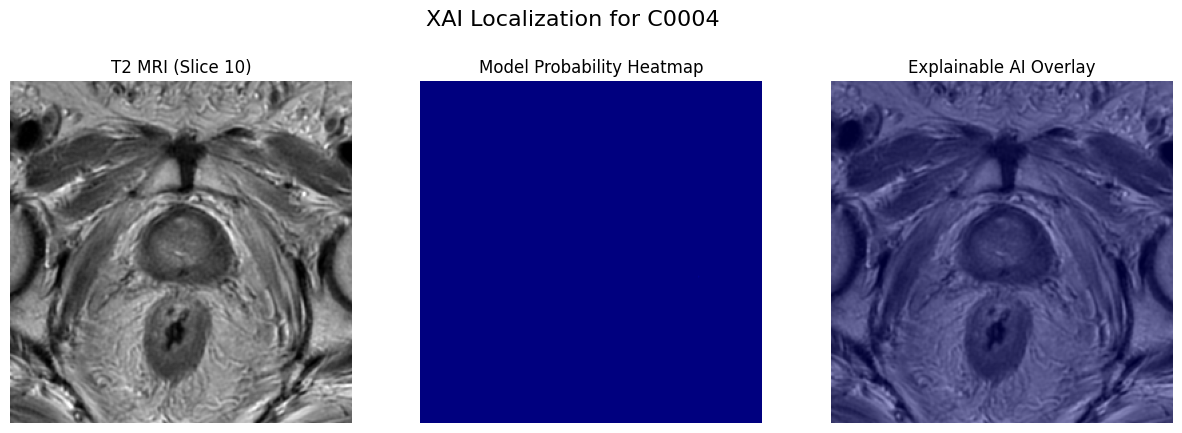

In [9]:
# ============================================================
# LOCAL TEST - SINGLE PATIENT
# ============================================================

import os
import glob
import numpy as np

# Find patient/case directories
test_cases = [
    path for path in glob.glob(os.path.join(IMAGES_DIR, "*"))
    if os.path.isdir(path)
]

print(f"Found {len(test_cases)} patient cases.")

if len(test_cases) == 0:

    print("\nNo patient cases found.")
    print("Please check your IMAGES_DIR:")
    print(IMAGES_DIR)

else:

    # --------------------------------------------------------
    # Select first patient
    # --------------------------------------------------------
    sample_case = test_cases[3]

    case_code = os.path.basename(
        os.path.normpath(sample_case)
    )

    print("\n========================================")
    print(f"Testing Patient: {case_code}")
    print(f"Path: {sample_case}")
    print("========================================")

    # --------------------------------------------------------
    # Check required MRI files
    # --------------------------------------------------------
    required_files = [
        "t2.nii.gz",
        "adc.nii.gz",
        "dwi_highb.nii.gz"
    ]

    missing_files = []

    for filename in required_files:

        filepath = os.path.join(
            sample_case,
            filename
        )

        if not os.path.exists(filepath):
            missing_files.append(filename)

    if missing_files:

        print("\nERROR: Missing MRI files:")

        for filename in missing_files:
            print(" -", filename)

    else:

        print("\nAll MRI files found.")

        # ----------------------------------------------------
        # Preprocessing
        # ----------------------------------------------------
        print("\nPreprocessing patient...")

        vol, meta = preprocess_case(sample_case)

        print("Preprocessing completed.")
        print("Volume shape:", vol.shape)

        # Expected:
        # (3, 20, 256, 256)

        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------
        print("\nRunning model prediction...")

        prob_map = predict(vol)

        print("Prediction completed.")
        print("Probability map shape:", prob_map.shape)

        # ----------------------------------------------------
        # Patient-level lesion score
        # ----------------------------------------------------
        lesion_map = extract_lesion_candidates(
            prob_map,
            threshold="dynamic"
        )[0]

        patient_score = float(
            np.max(lesion_map)
        )

        print(
            f"\nPatient Level Risk Score: "
            f"{patient_score:.4f}"
        )

        # ----------------------------------------------------
        # Find highest-probability slice
        # ----------------------------------------------------
        slice_scores = np.max(
            prob_map,
            axis=(1, 2)
        )

        best_slice = int(
            np.argmax(slice_scores)
        )

        print(
            f"Highest probability slice: "
            f"{best_slice}"
        )

        print(
            f"Maximum model probability: "
            f"{slice_scores[best_slice]:.4f}"
        )

        # ----------------------------------------------------
        # XAI Visualization
        # ----------------------------------------------------
        visualize_xai(
            vol[0],
            prob_map,
            case_code,
            slice_idx=best_slice
        )

In [10]:
!pip install -q ipywidgets

In [11]:
# ============================================================
# WHOLE DATASET EVALUATION
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from tqdm.notebook import tqdm

# 1. Load Ground Truth Labels
df_labels = pd.read_csv(LABELS_CSV)

# Map PI-RADS groups to Binary Labels: 0 (Normal: 1-2) and 1 (Lesion: 3, 4, 5)
def map_to_binary(pg):
    pg = str(pg).strip()
    if '1' in pg or '2' in pg: return 0
    if '3' in pg or '4' in pg or '5' in pg: return 1
    return -1

df_labels['binary_label'] = df_labels['pirads_group'].apply(map_to_binary)

# Create a dictionary for fast lookup: {'C0001': 1, 'C0002': 0, ...}
gt_dict = dict(zip(df_labels['code'], df_labels['binary_label']))

# Find patient/case directories
test_cases = [path for path in glob.glob(os.path.join(IMAGES_DIR, "*")) if os.path.isdir(path)]
print(f"Found {len(test_cases)} patient cases in directory.")

y_true_all = []
y_scores_all = []
evaluated_cases = 0

# 2. Iterate over all cases using a progress bar
for sample_case in tqdm(test_cases, desc="Evaluating AIIMS Dataset"):
    case_code = os.path.basename(os.path.normpath(sample_case))
    
    # Check if we have a valid ground truth label for this case
    if case_code not in gt_dict or gt_dict[case_code] == -1:
        continue

    # File existence check (handles both .nii and .nii.gz based on your preprocessing)
    if not os.path.exists(os.path.join(sample_case, "t2.nii.gz")) and \
       not os.path.exists(os.path.join(sample_case, "t2.nii")):
        continue # Skip if files are missing

    # Preprocessing
    try:
        vol, meta = preprocess_case(sample_case)
        
        # Prediction
        prob_map = predict(vol)
        
        # Patient-level lesion score (extract highest risk score in the 3D volume)
        lesion_map = extract_lesion_candidates(prob_map, threshold="dynamic")[0]
        patient_score = float(np.max(lesion_map))
        
        # Save true label and predicted probability
        y_true_all.append(gt_dict[case_code])
        y_scores_all.append(patient_score)
        evaluated_cases += 1
        
    except Exception as e:
        print(f"Error processing {case_code}: {e}")

# 3. Calculate and Print Evaluation Metrics
print("\n============================================================")
print("                 WHOLE DATASET METRICS")
print("============================================================")

if evaluated_cases > 0:
    y_true_all = np.array(y_true_all)
    y_scores_all = np.array(y_scores_all)
    
    # Calculate Primary Medical AI Metrics
    auc_score = roc_auc_score(y_true_all, y_scores_all)
    ap_score = average_precision_score(y_true_all, y_scores_all)
    
    # Generate binary predictions based on a standard 0.5 threshold
    threshold = 0.5
    y_pred_binary = (y_scores_all >= threshold).astype(int)
    
    print(f"Total Valid Cases Evaluated: {evaluated_cases}")
    print(f"Patient-Level ROC-AUC:       {auc_score:.4f}  <-- (Primary Benchmark)")
    print(f"Average Precision (PR-AUC):  {ap_score:.4f}  <-- (Lesion Detection Focus)")
    print("\nClassification Report (Threshold = 0.5):")
    print(classification_report(y_true_all, y_pred_binary, target_names=["Normal (0)", "Lesion (1)"]))

else:
    print("No cases were successfully evaluated. Please check file paths and CSV labels.")

Found 97 patient cases in directory.


Evaluating AIIMS Dataset:   0%|          | 0/97 [00:00<?, ?it/s]


                 WHOLE DATASET METRICS
Total Valid Cases Evaluated: 67
Patient-Level ROC-AUC:       0.7186  <-- (Primary Benchmark)
Average Precision (PR-AUC):  0.6529  <-- (Lesion Detection Focus)

Classification Report (Threshold = 0.5):
              precision    recall  f1-score   support

  Normal (0)       0.72      0.74      0.73        42
  Lesion (1)       0.54      0.52      0.53        25

    accuracy                           0.66        67
   macro avg       0.63      0.63      0.63        67
weighted avg       0.65      0.66      0.66        67

